# Project — Chapter 81: Epidemic Simulation

> **Prerequisites:** ch064 (Sigmoid), ch071 (Modeling), ch078 (Simulation)
>
> **Concepts used:** Logistic growth, sigmoid functions, ODE simulation, fitting
>
> **Output:** SIR epidemic model with parameter estimation and forecasting
>
> **Difficulty:** Intermediate | ~60 minutes

---

## 0. Overview

This is a Project chapter. Each stage builds on the previous. Read the problem statement, then execute the stages in order.

---

## 1. Setup

In [2]:
# --- Setup ---
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')

# Population parameters
N = 1_000_000   # total population
I0 = 100        # initial infected
R0_val = 2.5    # basic reproduction number
gamma = 1/14    # recovery rate (1/avg infectious period)
beta = R0_val * gamma  # transmission rate

print(f"SIR Model Parameters:")
print(f"  Population N = {N:,}")
print(f"  Initial infected I₀ = {I0}")
print(f"  R₀ = {R0_val} (reproduction number)")
print(f"  β = {beta:.4f} (transmission rate)")
print(f"  γ = {gamma:.4f} (recovery rate)")
print(f"  β/γ = {beta/gamma:.2f} (= R₀, sanity check)")

SIR Model Parameters:
  Population N = 1,000,000
  Initial infected I₀ = 100
  R₀ = 2.5 (reproduction number)
  β = 0.1786 (transmission rate)
  γ = 0.0714 (recovery rate)
  β/γ = 2.50 (= R₀, sanity check)


---

## 2. Stage 1 — SIR Model Simulation

Implement Euler integration of the SIR ODE system: dS/dt = -βSI/N, dI/dt = βSI/N - γI, dR/dt = γI.

C:\Users\user\AppData\Local\Temp\ipykernel_14636\216251447.py:52: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\user\OneDrive\Documents\book\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


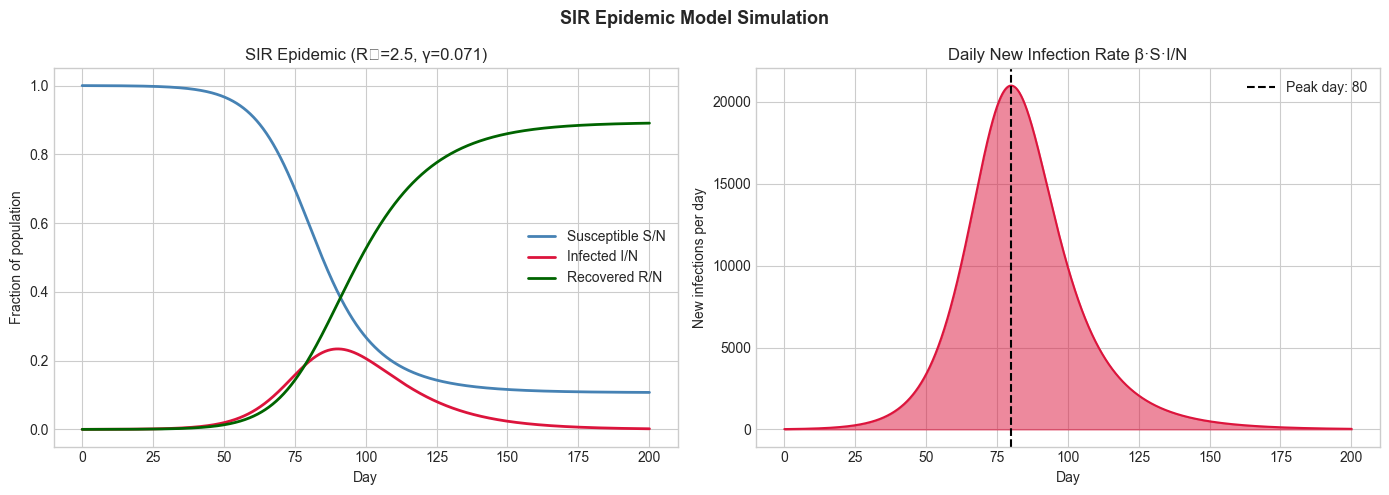

Peak infections: 23.4% of population on day 80
Final recovered (herd immunity): 89.1%


In [3]:
# Stage 1: SIR model simulation
def sir_euler(N, I0, beta, gamma, n_days=200, dt=0.1):
    """
    Simulate SIR epidemic model using Euler integration.
    dS/dt = -β*S*I/N
    dI/dt =  β*S*I/N - γ*I
    dR/dt =  γ*I
    """
    S = N - I0
    I = float(I0)
    R = 0.0
    
    history = {'t': [0], 'S': [S], 'I': [I], 'R': [R]}
    t = 0
    while t < n_days:
        dS = -beta * S * I / N * dt
        dI = (beta * S * I / N - gamma * I) * dt
        dR = gamma * I * dt
        S += dS; I += dI; R += dR
        t += dt
        history['t'].append(t)
        history['S'].append(S)
        history['I'].append(I)
        history['R'].append(R)
    
    return {k: np.array(v) for k, v in history.items()}

result = sir_euler(N, I0, beta, gamma)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Full SIR curves
t = result['t']
axes[0].plot(t, result['S']/N, color='steelblue', linewidth=2, label='Susceptible S/N')
axes[0].plot(t, result['I']/N, color='crimson', linewidth=2, label='Infected I/N')
axes[0].plot(t, result['R']/N, color='darkgreen', linewidth=2, label='Recovered R/N')
axes[0].set_title(f'SIR Epidemic (R₀={R0_val}, γ={gamma:.3f})')
axes[0].set_xlabel('Day'); axes[0].set_ylabel('Fraction of population')
axes[0].legend()

# Daily new cases (approximated)
new_cases_rate = beta * result['S'] * result['I'] / N
axes[1].fill_between(t, new_cases_rate, alpha=0.5, color='crimson')
axes[1].plot(t, new_cases_rate, color='crimson', linewidth=1.5)
peak_day = t[np.argmax(new_cases_rate)]
axes[1].axvline(peak_day, color='black', linestyle='--', label=f'Peak day: {peak_day:.0f}')
axes[1].set_title('Daily New Infection Rate β·S·I/N')
axes[1].set_xlabel('Day'); axes[1].set_ylabel('New infections per day')
axes[1].legend()

plt.suptitle('SIR Epidemic Model Simulation', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print(f"Peak infections: {result['I'].max()/N*100:.1f}% of population on day {peak_day:.0f}")
print(f"Final recovered (herd immunity): {result['R'][-1]/N*100:.1f}%")

---

## 3. Stage 2 — R₀ Sensitivity Analysis

Vary the reproduction number R₀ and observe how peak timing, peak height, and final attack rate change.

C:\Users\user\AppData\Local\Temp\ipykernel_14636\225931714.py:37: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  plt.tight_layout()


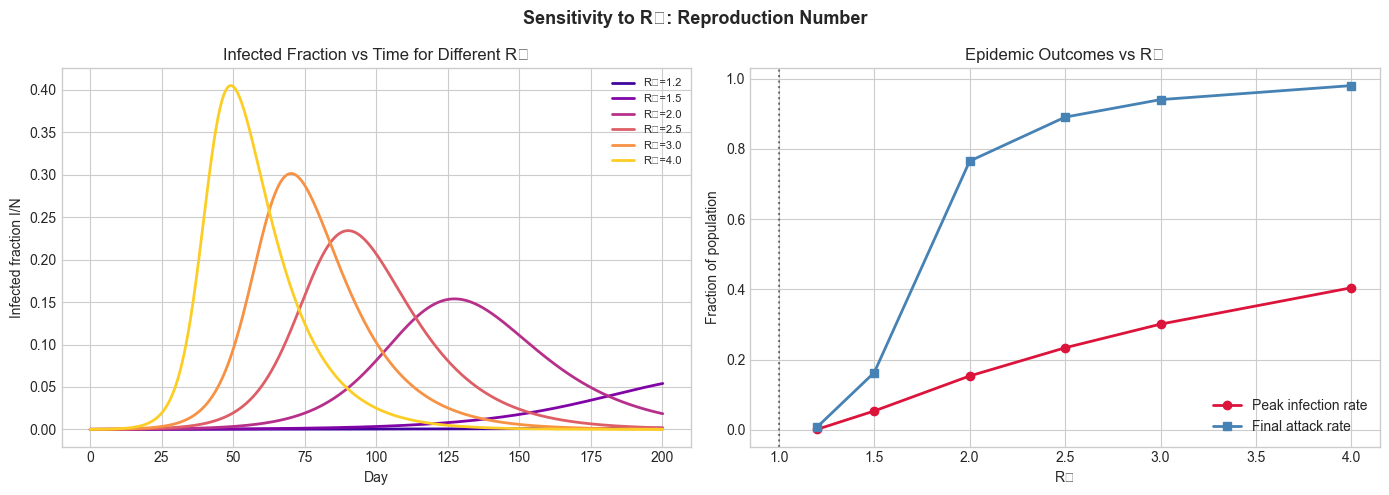

In [4]:
# Stage 2: R₀ sensitivity analysis
R0_values = [1.2, 1.5, 2.0, 2.5, 3.0, 4.0]
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = plt.cm.plasma(np.linspace(0.1, 0.9, len(R0_values)))

peak_days, peak_fracs, final_attacks = [], [], []

for R0_try, color in zip(R0_values, colors):
    beta_try = R0_try * gamma
    res = sir_euler(N, I0, beta_try, gamma)
    t = res['t']
    I_frac = res['I'] / N
    
    axes[0].plot(t, I_frac, color=color, linewidth=2, label=f'R₀={R0_try}')
    
    peak_day = t[np.argmax(I_frac)]
    peak_frac = I_frac.max()
    final_attack = res['R'][-1] / N
    
    peak_days.append(peak_day)
    peak_fracs.append(peak_frac)
    final_attacks.append(final_attack)

axes[0].set_title('Infected Fraction vs Time for Different R₀')
axes[0].set_xlabel('Day'); axes[0].set_ylabel('Infected fraction I/N')
axes[0].legend(fontsize=8)

ax2 = axes[1]
ax2.plot(R0_values, peak_fracs, 'o-', color='crimson', linewidth=2, label='Peak infection rate')
ax2.plot(R0_values, final_attacks, 's-', color='steelblue', linewidth=2, label='Final attack rate')
ax2.set_title('Epidemic Outcomes vs R₀')
ax2.set_xlabel('R₀'); ax2.set_ylabel('Fraction of population')
ax2.legend()
ax2.axvline(1, color='black', linestyle=':', alpha=0.5, label='Epidemic threshold R₀=1')

plt.suptitle('Sensitivity to R₀: Reproduction Number', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---

## 4. Stage 3 — Model Fitting to Observed Data

Generate synthetic observed case data and fit the SIR model parameters using grid search.

True:   β=0.180, γ=0.100, R₀=1.80
Fitted: β=0.153, γ=0.074, R₀=2.07


C:\Users\user\AppData\Local\Temp\ipykernel_14636\1794648928.py:39: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  plt.tight_layout(); plt.show()


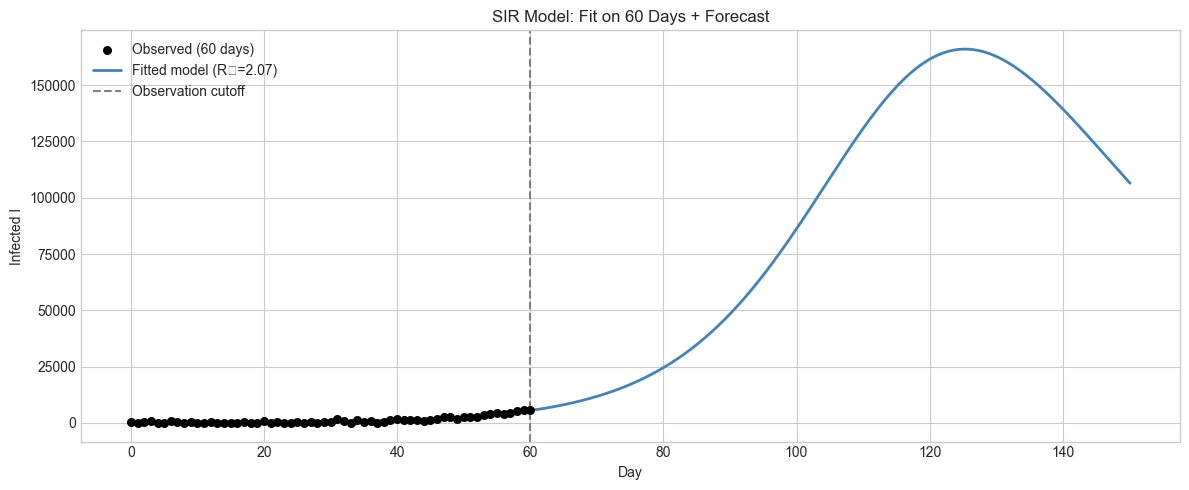

In [5]:
# Stage 3: Fit SIR to observed data
np.random.seed(42)

# Generate synthetic 'observed' data (first 60 days only)
true_beta, true_gamma = 0.18, 1/10
res_true = sir_euler(N, 50, true_beta, true_gamma, n_days=60)
observed_I = res_true['I'][::10]  # sample every 10th step
observed_t = res_true['t'][::10]
# Add noise
observed_I = np.maximum(0, observed_I + np.random.normal(0, 500, len(observed_I)))

# Grid search
best_mse, best_params = np.inf, None
beta_grid = np.linspace(0.10, 0.30, 20)
gamma_grid = np.linspace(0.05, 0.20, 20)

for b in beta_grid:
    for g in gamma_grid:
        res = sir_euler(N, 50, b, g, n_days=60)
        sim_I = np.interp(observed_t, res['t'], res['I'])
        mse = np.mean((sim_I - observed_I)**2)
        if mse < best_mse:
            best_mse, best_params = mse, (b, g)

b_fit, g_fit = best_params
R0_fit = b_fit / g_fit
print(f"True:   β={true_beta:.3f}, γ={true_gamma:.3f}, R₀={true_beta/true_gamma:.2f}")
print(f"Fitted: β={b_fit:.3f}, γ={g_fit:.3f}, R₀={R0_fit:.2f}")

# Forecast beyond day 60
res_fit = sir_euler(N, 50, b_fit, g_fit, n_days=150)

fig, ax = plt.subplots(figsize=(12, 5))
ax.scatter(observed_t, observed_I, color='black', s=30, zorder=5, label='Observed (60 days)')
ax.plot(res_fit['t'], res_fit['I'], color='steelblue', linewidth=2, label=f'Fitted model (R₀={R0_fit:.2f})')
ax.axvline(60, color='gray', linestyle='--', label='Observation cutoff')
ax.set_title('SIR Model: Fit on 60 Days + Forecast'); ax.set_xlabel('Day'); ax.set_ylabel('Infected I')
ax.legend()
plt.tight_layout(); plt.show()

---

## 5. Results & Reflection

**What was built:**
A complete epidemic simulation pipeline: SIR model implementation, R₀ sensitivity analysis, and parameter fitting to observational data.

**What math made it possible:**
- Logistic/sigmoid growth structure (ch064) — the infected curve is S-shaped in cumulative cases
- ODE simulation via Euler integration (ch078)
- Parameter sensitivity analysis (ch069)
- Grid-search model fitting (ch071, ch072)

**Extension challenges:**
1. Add vaccination: a fraction v of susceptibles moves to R each day. How does peak change vs v?
2. Implement the SEIR model: add an Exposed (E) compartment between S and I
3. Add spatial structure: simulate two populations with travel between them